# Pipeline Dự báo Vàng (Gold) bằng PyTorch Vanilla RNN

Notebook này thực thi toàn bộ pipeline PyTorch để dự báo giá cả sử dụng RNN Vanilla, LSTM hoặc RNN.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import os

# Đặt seed để đảm bảo tính tái lập
torch.manual_seed(42)
np.random.seed(42)
os.makedirs('../models', exist_ok=True)

## Bước 1: Tiền Xử lý Dữ liệu & Kỹ thuật Chuỗi
- Làm sạch dữ liệu, xử lý thời gian
- Chia tập dữ liệu theo thời gian (70% Train, 15% Val, 15% Test)
- Chia tỷ lệ bằng `MinMaxScaler(-1, 1)` CHỈ TRÊN TẬP HUẤN LUYỆN (Train)
- Tạo chuỗi tensor 3D cửa sổ trượt: `(batch_size, sequence_length, feature_dim)`

In [20]:
df = pd.read_csv('../data/gold_price.csv')
date_col = 'Date' if 'Date' in df.columns else df.columns[0]
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)
df.sort_index(inplace=True)

target_col = 'Close' if 'Close' in df.columns else ('Price' if 'Price' in df.columns else df.columns[0])
df[target_col] = df[target_col].ffill().bfill()
data = df[[target_col]].values

# Chia tập dữ liệu theo thứ tự thời gian
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

# Khởi tạo và Fit Scaler CHỈ trên Train
scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# Hàm tạo chuỗi
def create_sequences(data_array, seq_length=30):
    xs, ys = [], []
    for i in range(len(data_array) - seq_length):
        xs.append(data_array[i:(i + seq_length)])
        ys.append(data_array[i + seq_length])
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 30
X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_val, y_val = create_sequences(val_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)

# Tạo PyTorch DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.Tensor(y_train)), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.Tensor(y_val)), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.Tensor(X_test), torch.Tensor(y_test)), batch_size=batch_size, shuffle=False)
print(f"Kích thước X_train: {X_train.shape}")

Kích thước X_train: (9392, 30, 1)


## Bước 2: Thiết kế Kiến trúc Mô hình
Xây dựng kiến trúc RNN dự báo chuỗi thời gian nhiều-thành-một (Many-to-One).

In [21]:
class TimeSeriesModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.2):
        super(TimeSeriesModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1) # V projection

    def forward(self, x):
        out, _ = self.rnn(x)
        # Lấy trạng thái ẩn tại bước thời gian cuối cùng
        last_hidden = out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        y_hat = self.fc(last_hidden)
        return y_hat

model = TimeSeriesModel()
print(model)

TimeSeriesModel(
  (rnn): RNN(1, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## Bước 3: Cấu hình Huấn luyện
- Hàm mất mát (Loss): MSE
- Bộ tối ưu hóa: Adam
- Cắt xén Đạo hàm (Gradient Clipping): `max_norm=1.0`
- Trình lập lịch LR (LR Scheduler): Giảm khi Loss hội tụ (ReduceLROnPlateau)

In [22]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

## Bước 4: Vòng lặp Huấn luyện & Chẩn đoán (BPTT)
Theo dõi Train/Val Loss, EarlyStopping và vẽ đường cong hội tụ.

Epoch [001/100] | Train Loss: 0.00064 | Val Loss: 0.05408 | Best Val: 0.05408 | LR: 0.000016
Epoch [002/100] | Train Loss: 0.00064 | Val Loss: 0.05150 | Best Val: 0.05150 | LR: 0.000016
Epoch [003/100] | Train Loss: 0.00061 | Val Loss: 0.05297 | Best Val: 0.05150 | LR: 0.000016
Epoch [004/100] | Train Loss: 0.00065 | Val Loss: 0.05217 | Best Val: 0.05150 | LR: 0.000016
Epoch [005/100] | Train Loss: 0.00064 | Val Loss: 0.05343 | Best Val: 0.05150 | LR: 0.000008
Epoch [006/100] | Train Loss: 0.00064 | Val Loss: 0.05103 | Best Val: 0.05103 | LR: 0.000008
Epoch [007/100] | Train Loss: 0.00063 | Val Loss: 0.05122 | Best Val: 0.05103 | LR: 0.000008
Epoch [008/100] | Train Loss: 0.00064 | Val Loss: 0.05020 | Best Val: 0.05020 | LR: 0.000008
Epoch [009/100] | Train Loss: 0.00063 | Val Loss: 0.05094 | Best Val: 0.05020 | LR: 0.000008
Epoch [010/100] | Train Loss: 0.00066 | Val Loss: 0.05178 | Best Val: 0.05020 | LR: 0.000008
Epoch [011/100] | Train Loss: 0.00063 | Val Loss: 0.05213 | Best Val: 

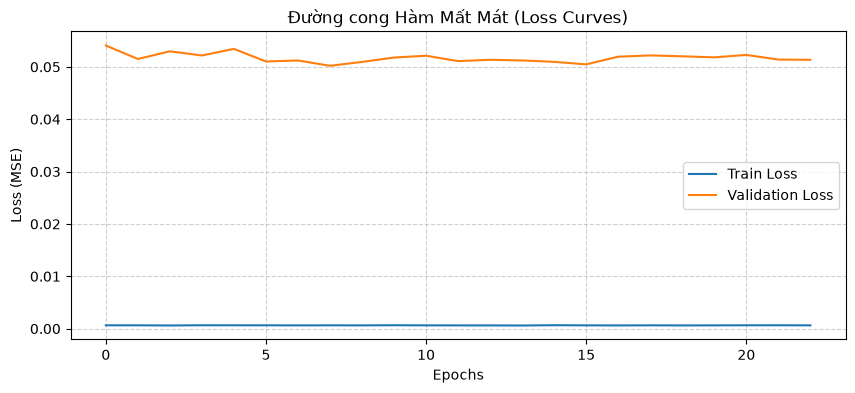

In [27]:
epochs = 100
patience = 15
divergence_threshold = 2.0  # Dừng ngay nếu val_loss tăng vọt gấp 2 lần best_val_loss

best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    # 1. Training Phase
    model.train()
    total_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_train_loss += loss.item() * len(X_batch)
        
    epoch_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # 2. Validation Phase
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_val_loss += loss.item() * len(X_batch)
            
    epoch_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Cập nhật Learning Rate Scheduler
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # 3. Thông báo log mỗi 10 epochs (hoặc epoch đầu/cuối)
    if epoch % 10s == 0 or epoch == 1:
        print(f"Epoch [{epoch:03d}/{epochs:03d}] | "
              f"Train Loss: {epoch_train_loss:.5f} | "
              f"Val Loss: {epoch_val_loss:.5f} | "
              f"Best Val: {min(best_val_loss, epoch_val_loss):.5f} | "
              f"LR: {current_lr:.6f}")

    # 4. Kiểm tra ngắt nếu Loss tăng đột biến hoặc bị nổ (NaN / Divergence)
    if np.isnan(epoch_val_loss) or np.isinf(epoch_val_loss):
        print(f"\n[CẢNH BÁO] Dừng khẩn cấp tại epoch {epoch}: Loss bị NaN/Inf!")
        break
        
    if best_val_loss != float('inf') and epoch_val_loss > best_val_loss * divergence_threshold:
        print(f"\n[DỪNG SỚM] Dừng tại epoch {epoch}: Val loss tăng vọt ({epoch_val_loss:.5f} > {best_val_loss * divergence_threshold:.5f})!")
        break

    # 5. Lưu trọng số tốt nhất & Early Stopping thông thường
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '../models/pytorch_rnn_gold.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n[DỪNG SỚM] Đạt giới hạn patience ({patience} epochs không giảm loss) tại epoch {epoch}!")
            break

# Vẽ đồ thị sau khi kết thúc
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='#1f77b4')
plt.plot(val_losses, label='Validation Loss', color='#ff7f0e')
plt.title('Đường cong Hàm Mất Mát (Loss Curves)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Bước 5: Đánh giá Độc lập & Chẩn đoán trên Tập Kiểm tra
Tính toán RMSE, MAE, MAPE trên giá trị gốc (inverse-transformed). Đánh giá tính chính xác về hướng đi (Directional Accuracy).

RMSE (Tập Kiểm tra): 109.9357
MAE (Tập Kiểm tra):  95.8728
MAPE (Tập Kiểm tra): 0.0674
Độ chính xác về hướng: 0.5018


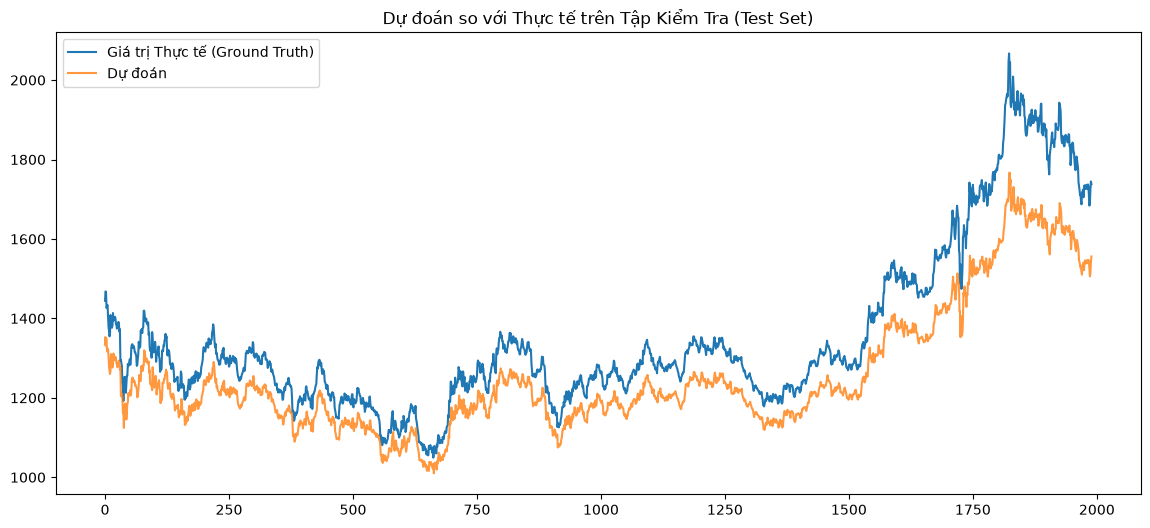

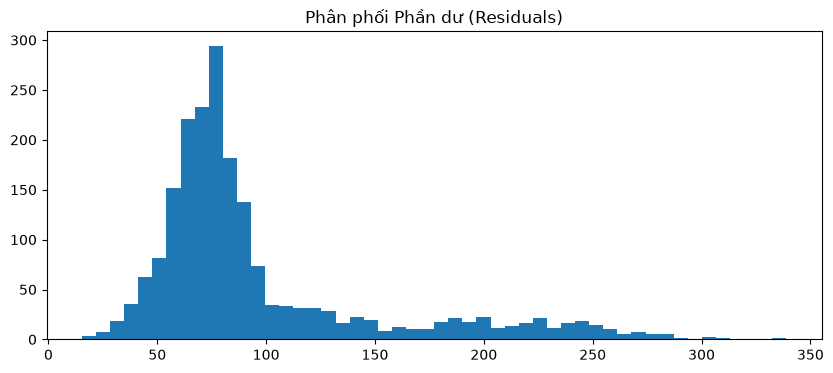

In [28]:
# Tải model weights tốt nhất
model.load_state_dict(torch.load('../models/pytorch_rnn_gold.pth'))
model.eval()
preds, targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds.append(model(X_batch).numpy())
        targets.append(y_batch.numpy())
preds = np.concatenate(preds)
targets = np.concatenate(targets)

# Chuyển đổi ngược về giá trị gốc
preds_inv = scaler.inverse_transform(preds)
targets_inv = scaler.inverse_transform(targets)

# Các chỉ số
rmse = np.sqrt(mean_squared_error(targets_inv, preds_inv))
mae = mean_absolute_error(targets_inv, preds_inv)
mape = mean_absolute_percentage_error(targets_inv, preds_inv)

# Độ chính xác về hướng đi (Directional Accuracy)
actual_diff = np.diff(targets_inv.flatten())
pred_diff = np.diff(preds_inv.flatten())
directional_acc = np.mean(np.sign(actual_diff) == np.sign(pred_diff))

print(f"RMSE (Tập Kiểm tra): {rmse:.4f}")
print(f"MAE (Tập Kiểm tra):  {mae:.4f}")
print(f"MAPE (Tập Kiểm tra): {mape:.4f}")
print(f"Độ chính xác về hướng: {directional_acc:.4f}")

# Vẽ đồ thị kết quả
plt.figure(figsize=(14, 6))
plt.plot(targets_inv, label='Giá trị Thực tế (Ground Truth)')
plt.plot(preds_inv, label='Dự đoán', alpha=0.8)
plt.title('Dự đoán so với Thực tế trên Tập Kiểm Tra (Test Set)')
plt.legend()
plt.show()

# Biểu đồ phần dư
plt.figure(figsize=(10, 4))
plt.hist(targets_inv - preds_inv, bins=50)
plt.title('Phân phối Phần dư (Residuals)')
plt.show()

## Bước 6: Tuần tự hóa (Serialization) & Kiểm chứng
Xuất bundle cấu hình dạng `.pkl` kèm theo thông số metrics.

In [18]:
bundle = {
    "model_name": "pytorch_rnn_gold",
    "framework": "pytorch",
    "target_column": target_col,
    "seq_length": SEQ_LENGTH,
    "scaler": scaler,
    "metrics": {
        "rmse": float(rmse),
        "mae": float(mae),
        "mape": float(mape),
        "directional_acc": float(directional_acc)
    },
    "model_path": "models/pytorch_rnn_gold.pth"
}
with open('../models/pytorch_rnn_gold.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print(f"Đã xuất bundle thành công ra: models/pytorch_rnn_gold.pkl")

Đã xuất bundle thành công ra: models/pytorch_rnn_gold.pkl
